In [1]:
import pandas as pd


In [2]:
performance = pd.read_csv("../results/performance_tracking_new.csv")
len(performance)


4871

In [3]:
len(performance)
# 4659

4871

In [4]:
performance.query("dataset_name == 'concatenated_domains'")

performance.query("grading_model == 'bert-base-cased' and dataset_name == 'concatenated_domains' and dataset_split == 'validation' and left_out_dataset == 'biology'")["time_stamp"]


4746    2023-06-08 16:24:22
4826    2023-06-11 23:23:09
Name: time_stamp, dtype: object

## Columns

In [5]:
performance.columns


Index(['row_id', 'embedding_seperated', 'embedding_model_name',
       'sentence_embedding_method', 'feature_engenearing', 'grading_model',
       'dataset_name', 'dataset_split', 'seed_data_split', 'left_out_dataset',
       'description', 'shots', 'epochs', 'finished_pred', 'last_pred_index',
       'time_stamp', 'rmse', 'pears_correlation', 'p_value', 'accuracy',
       'precision_macro', 'recall_macro', 'f1_macro', 'precision_micro',
       'recall_micro', 'f1_micro', 'precision_weighted', 'recall_weighted',
       'f1_weighted'],
      dtype='object')

## Quick look at tables

### filtered look at table

In [6]:
# performance.tail(50)["grading_model"]


In [7]:
performance.query("grading_model == 'gpt-3.5-turbo' and description == 'zero_shot_real'")[["accuracy", "epochs", "time_stamp", "grading_model", "dataset_name", "left_out_dataset", "time_stamp", "finished_pred", "dataset_split", "description"]]

# len(performance.query("grading_model == 'gpt-3.5-turbo' and shots == 5"))


,accuracy,epochs,time_stamp,grading_model,dataset_name,left_out_dataset,time_stamp,finished_pred,dataset_split,description
4781,0.581571,0,2023-06-10 01:21:10,gpt-3.5-turbo,beetle,NaN,2023-06-10 01:21:10,True,validation,zero_shot_real
4782,0.553704,0,2023-06-10 01:29:45,gpt-3.5-turbo,english,NaN,2023-06-10 01:29:45,True,validation,zero_shot_real
4783,0.153509,0,2023-06-10 01:38:04,gpt-3.5-turbo,texas,NaN,2023-06-10 01:38:04,True,validation,zero_shot_real
4784,0.705556,0,2023-06-10 01:41:03,gpt-3.5-turbo,biology,NaN,2023-06-10 01:41:03,True,validation,zero_shot_real
4785,0.556072,0,2023-06-10 01:47:15,gpt-3.5-turbo,ASAP_sas,NaN,2023-06-10 01:47:15,True,validation,zero_shot_real
4786,0.523077,0,2023-06-10 02:08:08,gpt-3.5-turbo,neural_course,NaN,2023-06-10 02:08:08,True,validation,zero_shot_real
4787,0.577097,0,2023-06-10 02:09:13,gpt-3.5-turbo,concatenated_datasets,NaN,2023-06-10 02:09:13,True,validation,zero_shot_real
4788,0.540594,0,2023-06-10 03:07:13,gpt-3.5-turbo,concatenated_datasets,ASAP_sas,2023-06-10 03:07:13,True,validation,zero_shot_real
4789,0.680870,0,2023-06-10 17:16:08,gpt-3.5-turbo,concatenated_datasets,beetle,2023-06-10 17:16:08,True,validation,zero_shot_real
4790,0.527864,0,2023-06-10 19:30:39,gpt-3.5-turbo,concatenated_datasets,neural_course,2023-06-10 19:30:39,True,validation,zero_shot_real


## last few restuls

In [8]:
performance.tail(20)[["accuracy", "epochs", "time_stamp", "grading_model", "dataset_name", "left_out_dataset", "finished_pred", "dataset_split"]]


,accuracy,epochs,time_stamp,grading_model,dataset_name,left_out_dataset,finished_pred,dataset_split
4851,0.547988,0,2023-06-13 17:09:05,gpt-3.5-turbo,concatenated_domains,neural_networks,True,validation
4852,0.355469,10,2023-06-13 16:04:02,bert-base-cased,concatenated_datasets,texas,True,train
4853,0.653125,10,2023-06-13 16:04:02,bert-base-cased,concatenated_datasets,texas,True,test
4854,0.222500,10,2023-06-13 16:04:02,bert-base-cased,concatenated_datasets,texas,True,validation
4855,0.367332,0,2023-06-13 18:11:53,gpt-3.5-turbo,concatenated_domains,science,True,validation
4856,0.621647,0,2023-06-13 21:22:05,gpt-3.5-turbo,sciEntsBank,NaN,True,validation
4857,0.570423,0,2023-06-17 22:13:06,gpt-3.5-turbo,concatenated_domains,english,True,validation
4858,0.227344,5,2023-06-17 22:44:32,bert-base-cased,concatenated_datasets,ASAP_sas,True,train
4859,0.540625,5,2023-06-17 22:44:33,bert-base-cased,concatenated_datasets,ASAP_sas,True,test
4860,0.325000,5,2023-06-17 22:44:33,bert-base-cased,concatenated_datasets,ASAP_sas,True,validation


## Dataset insights

In [72]:
# accuracy
performance.groupby('dataset_name')['accuracy'].agg(['mean', 'std', 'max', 'min'])



,mean,std,max,min
dataset_name,,,,
ASAP_sas,0.374477,0.040292,0.547500,0.265000
beetle,0.678177,0.021950,0.835000,0.635952
biology,0.769874,0.050088,0.835000,0.500714
concatenated_datasets,0.443337,0.150062,0.684799,0.043995
concatenated_domains,0.299115,0.077958,0.578947,0.068764
english,0.367481,0.064095,0.522222,0.269791
english_language_arts,0.456432,0.021467,0.530315,0.410468
neural_course,0.370259,0.054681,0.600000,0.331858
neural_networks,0.371284,0.056672,0.630769,0.331858


In [73]:
performance.groupby('dataset_name')['f1_weighted'].agg(['mean', 'std', 'max', 'min'])


,mean,std,max,min
dataset_name,,,,
ASAP_sas,0.336227,0.060718,0.553823,0.111028
beetle,0.670334,0.024993,0.835673,0.605580
biology,0.729137,0.030558,0.822519,0.566706
concatenated_datasets,0.411419,0.170330,0.672082,0.017674
concatenated_domains,0.213499,0.070897,0.546803,0.027294
english,0.311243,0.103672,0.513089,0.118627
english_language_arts,0.356052,0.033483,0.469024,0.285618
neural_course,0.225970,0.108517,0.574414,0.165378
neural_networks,0.226402,0.107642,0.571621,0.165378


## model insights

### grading model

In [60]:
performance.groupby('grading_model')['accuracy'].agg(['mean', 'std', 'max', 'min'])
stats_df = performance.groupby('grading_model')['accuracy'].agg(['mean', 'std', 'max', 'min']).reset_index()
stats_df


,grading_model,mean,std,max,min
0,Isotonic Regression,0.420533,0.152641,0.826173,0.043995
1,Linear Regression,0.413998,0.159646,0.827367,0.062912
2,Ridge Regression,0.413356,0.159523,0.831344,0.062912
3,bert-base-cased,0.496471,0.179681,0.835000,0.226562
4,distilbert-base-cased,0.395549,0.199840,0.835000,0.265000
5,gpt-3.5-turbo,0.536587,0.120472,0.765032,0.273647


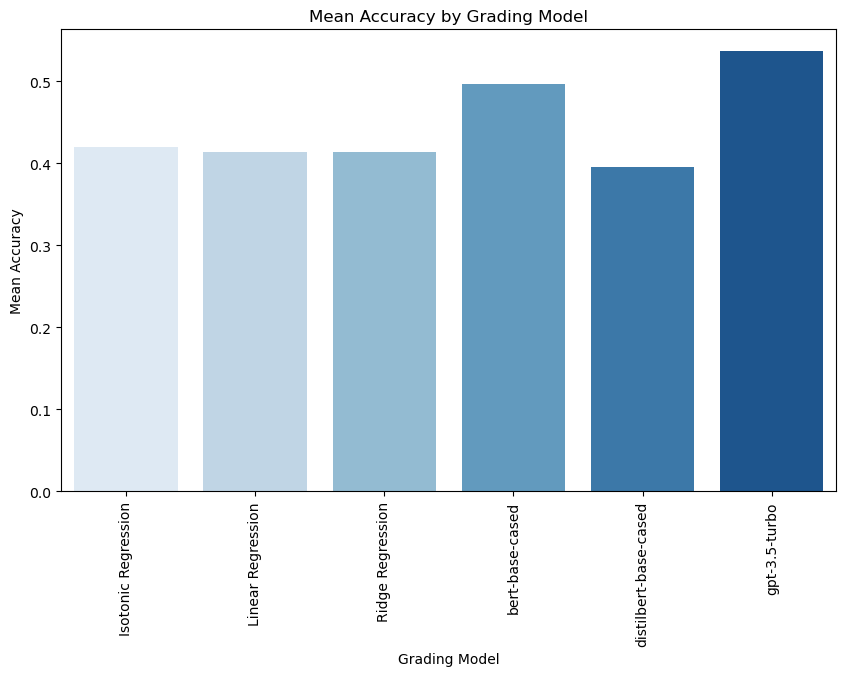

In [61]:
plt.figure(figsize=(10,6))
sns.barplot(x='grading_model', y='mean', data=stats_df, palette='Blues')
plt.title('Mean Accuracy by Grading Model')
plt.ylabel('Mean Accuracy')
plt.xlabel('Grading Model')
plt.xticks(rotation=90)
plt.show()


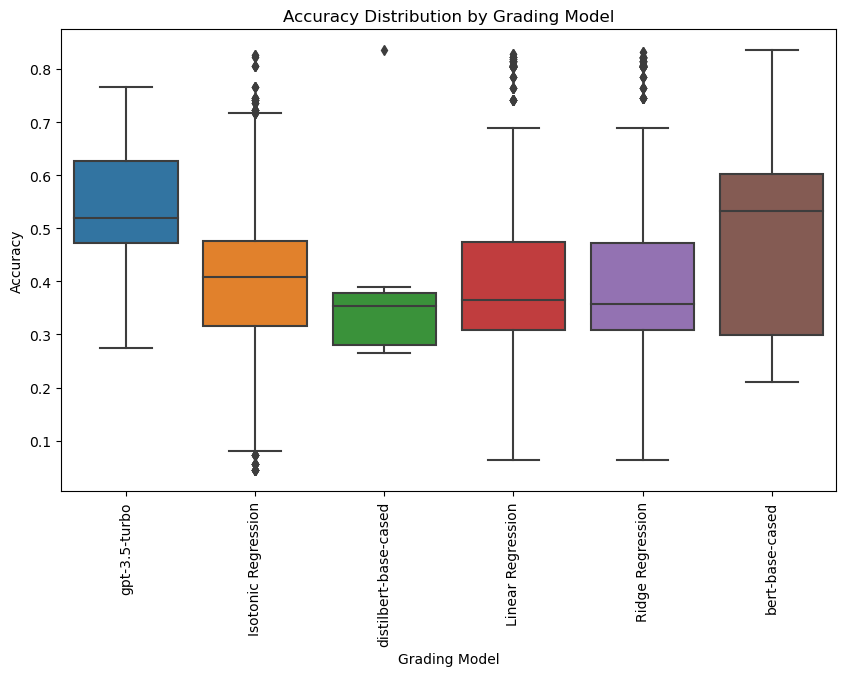

In [75]:
plt.figure(figsize=(10,6))
sns.boxplot(x='grading_model', y='accuracy', data=performance)
plt.title('Accuracy Distribution by Grading Model')
plt.ylabel('Accuracy')
plt.xlabel('Grading Model')
plt.xticks(rotation=90)
plt.show()


In [76]:
# create a grouped DataFrame with mean accuracy for each model on each dataset
grouped_performance = performance.groupby(['grading_model', 'dataset_name'])['accuracy'].mean()

# create a DataFrame to store the results
best_worst_df = pd.DataFrame(columns=['grading_model', 'best_dataset', 'best_accuracy', 'worst_dataset', 'worst_accuracy'])

# iterate over each grading model
for model in performance['grading_model'].unique():
    # get the dataset with maximum and minimum mean accuracy for the current model
    best_dataset = grouped_performance[model].idxmax()
    worst_dataset = grouped_performance[model].idxmin()

    # get the mean accuracy for the best and worst datasets
    best_accuracy = grouped_performance[model][best_dataset]
    worst_accuracy = grouped_performance[model][worst_dataset]
    
    # append the result to the results DataFrame
    best_worst_df = best_worst_df.append({
        'grading_model': model,
        'best_dataset': best_dataset,
        'best_accuracy': best_accuracy,
        'worst_dataset': worst_dataset,
        'worst_accuracy': worst_accuracy
    }, ignore_index=True)


In [78]:
best_worst_df


,grading_model,best_dataset,best_accuracy,worst_dataset,worst_accuracy
0,gpt-3.5-turbo,sciEntsBank,0.750540,english_language_arts,0.413912
1,Isotonic Regression,biology,0.734434,concatenated_domains,0.298581
2,distilbert-base-cased,biology,0.835000,ASAP_sas,0.265000
3,Linear Regression,biology,0.794198,science,0.293112
4,Ridge Regression,biology,0.794771,science,0.292978
5,bert-base-cased,beetle,0.815000,english,0.435000


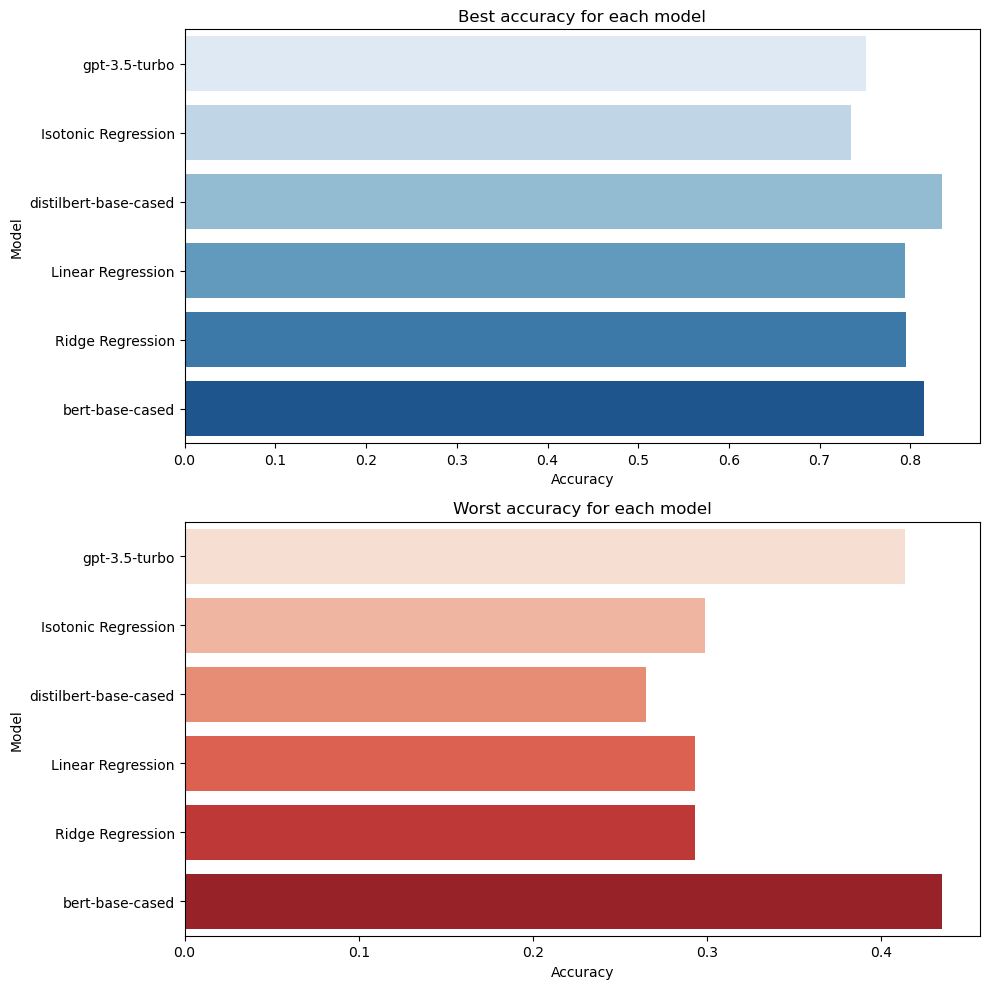

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# create a figure and axes
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

# create a bar plot for the best accuracy
sns.barplot(x='best_accuracy', y='grading_model', data=best_worst_df, ax=ax1, orient='h', palette='Blues')
ax1.set_title('Best accuracy for each model')
ax1.set_xlabel('Accuracy')
ax1.set_ylabel('Model')

# create a bar plot for the worst accuracy
sns.barplot(x='worst_accuracy', y='grading_model', data=best_worst_df, ax=ax2, orient='h', palette='Reds')
ax2.set_title('Worst accuracy for each model')
ax2.set_xlabel('Accuracy')
ax2.set_ylabel('Model')

# show the plot
plt.tight_layout()
plt.show()


## cross_validation

In [84]:
cross_validation = performance.query("left_out_dataset.notnull()")


In [85]:
cross_validation.head(2)


,row_id,embedding_seperated,embedding_model_name,sentence_embedding_method,feature_engenearing,grading_model,dataset_name,dataset_split,seed_data_split,left_out_dataset,...,accuracy,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,precision_weighted,recall_weighted,f1_weighted
21,21,True,embed_words_conceptnet,avg,cosine_similarity,Isotonic Regression,concatenated_datasets,validation,42,sciEntsBank,...,0.659108,0.659973,0.614113,0.606726,0.659108,0.659108,0.659108,0.659701,0.659108,0.631781
28,28,False,gpt-3.5-turbo,NaN,NaN,gpt-3.5-turbo,concatenated_datasets,validation,42,ASAP_sas,...,0.412390,0.351306,0.266841,0.271718,0.412390,0.412390,0.412390,0.523944,0.412390,0.435507


In [86]:
stats_df_cross_validation = cross_validation.groupby('grading_model')['accuracy'].agg(['mean', 'std', 'max', 'min']).reset_index()
stats_df_cross_validation


,grading_model,mean,std,max,min
0,Isotonic Regression,0.370627,0.150960,0.684799,0.043995
1,Linear Regression,0.368865,0.147905,0.676186,0.062912
2,Ridge Regression,0.368808,0.147481,0.676186,0.062912
3,bert-base-cased,0.443229,0.176490,0.621875,0.210156
4,gpt-3.5-turbo,0.459710,0.135576,0.682340,0.273647


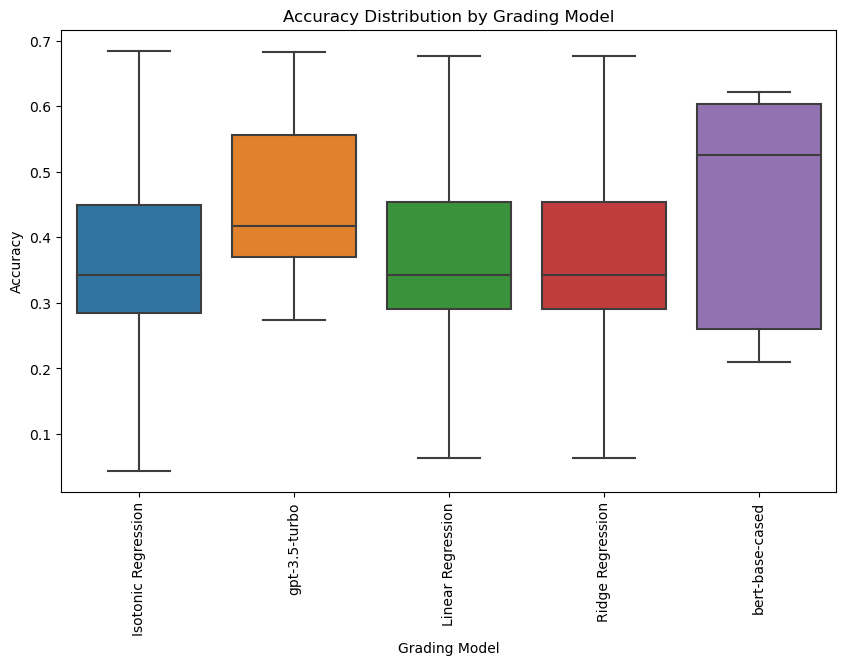

In [87]:
plt.figure(figsize=(10,6))
sns.boxplot(x='grading_model', y='accuracy', data=cross_validation)
plt.title('Accuracy Distribution by Grading Model')
plt.ylabel('Accuracy')
plt.xlabel('Grading Model')
plt.xticks(rotation=90)
plt.show()


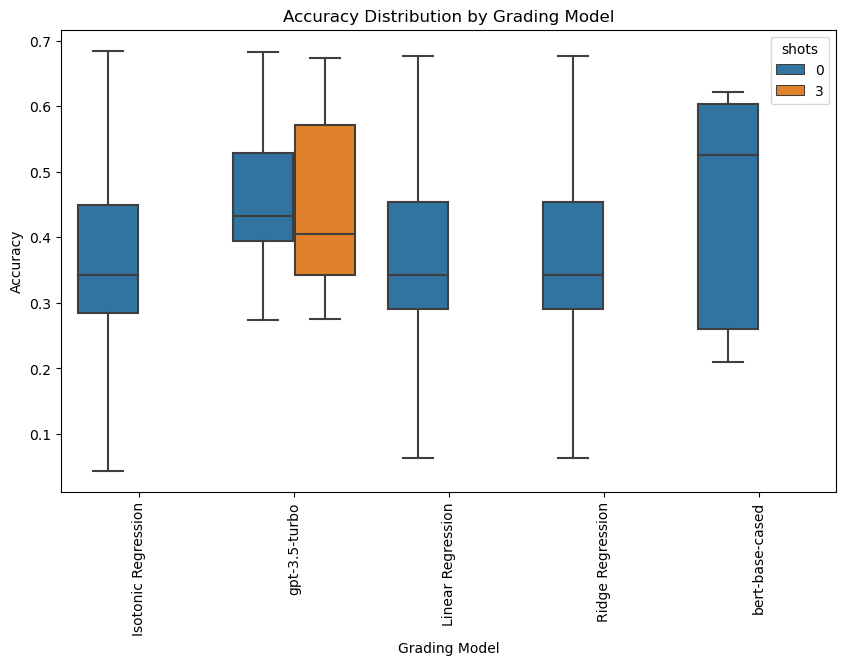

In [103]:
plt.figure(figsize=(10,6))
sns.boxplot(x='grading_model', y='accuracy', hue='shots', data=cross_validation)
plt.title('Accuracy Distribution by Grading Model')
plt.ylabel('Accuracy')
plt.xlabel('Grading Model')
plt.xticks(rotation=90)
plt.show()


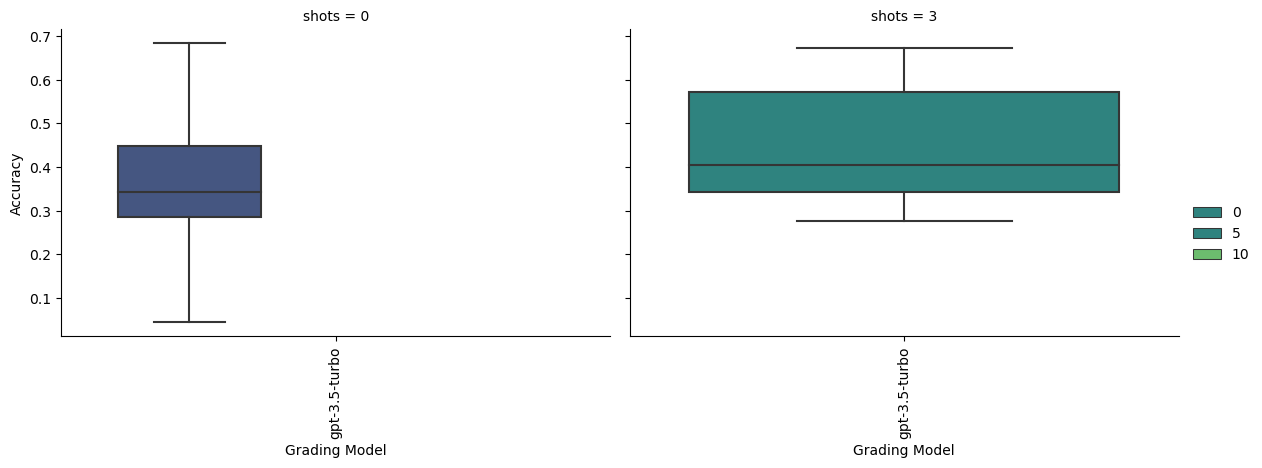

In [100]:
g = sns.FacetGrid(cross_validation, col="shots", height=4, aspect=1.5)
g.map(sns.boxplot, 'grading_model', 'accuracy', 'epochs', palette='viridis')
g.add_legend()

# Optional: adjust labels and rotation of xticks
g.set_axis_labels("Grading Model", "Accuracy")
g.set_xticklabels(rotation=90)

plt.show()


In [83]:
# create a grouped DataFrame with mean accuracy for each model on each dataset
grouped_performance = cross_validation.groupby(['grading_model', 'dataset_name'])['accuracy'].mean()

# create a DataFrame to store the results
best_worst_df = pd.DataFrame(columns=['grading_model', 'best_dataset', 'best_accuracy', 'worst_dataset', 'worst_accuracy'])

# iterate over each grading model
for model in cross_validation['grading_model'].unique():
    # get the dataset with maximum and minimum mean accuracy for the current model
    best_dataset = grouped_performance[model].idxmax()
    worst_dataset = grouped_performance[model].idxmin()

    # get the mean accuracy for the best and worst datasets
    best_accuracy = grouped_performance[model][best_dataset]
    worst_accuracy = grouped_performance[model][worst_dataset]
    
    # append the result to the results DataFrame
    best_worst_df = best_worst_df.append({
        'grading_model': model,
        'best_dataset': best_dataset,
        'best_accuracy': best_accuracy,
        'worst_dataset': worst_dataset,
        'worst_accuracy': worst_accuracy
    }, ignore_index=True)


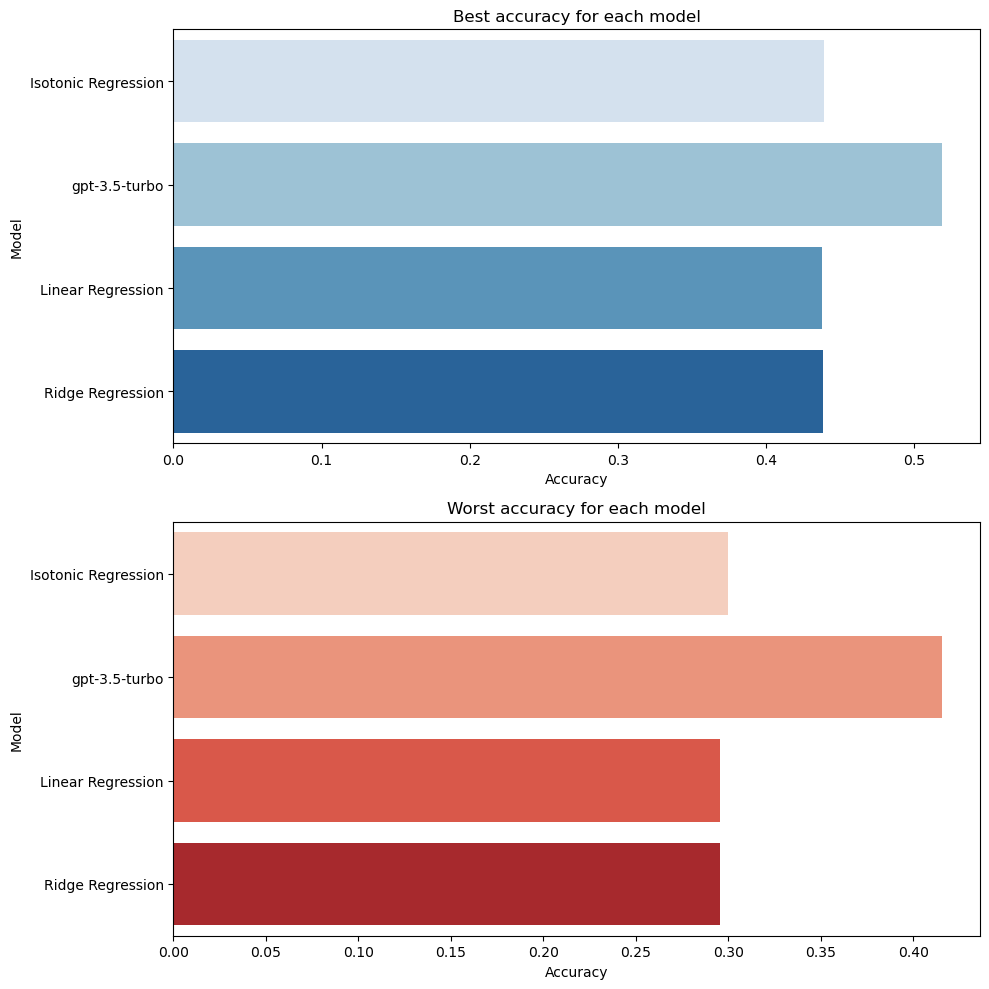

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# create a figure and axes
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

# create a bar plot for the best accuracy
sns.barplot(x='best_accuracy', y='grading_model', data=best_worst_df, ax=ax1, orient='h', palette='Blues')
ax1.set_title('Best accuracy for each model')
ax1.set_xlabel('Accuracy')
ax1.set_ylabel('Model')

# create a bar plot for the worst accuracy
sns.barplot(x='worst_accuracy', y='grading_model', data=best_worst_df, ax=ax2, orient='h', palette='Reds')
ax2.set_title('Worst accuracy for each model')
ax2.set_xlabel('Accuracy')
ax2.set_ylabel('Model')

# show the plot
plt.tight_layout()
plt.show()


In [97]:
# create a grouped DataFrame with mean accuracy for each model on each dataset
grouped_performance = cross_validation.groupby(['grading_model', 'left_out_dataset'])['accuracy'].mean()

# create a DataFrame to store the results
best_worst_df = pd.DataFrame(columns=['grading_model', 'best_dataset', 'best_accuracy', 'worst_dataset', 'worst_accuracy'])

# iterate over each grading model
for model in cross_validation['grading_model'].unique():
    # get the dataset with maximum and minimum mean accuracy for the current model
    best_dataset = grouped_performance[model].idxmax()
    worst_dataset = grouped_performance[model].idxmin()

    # get the mean accuracy for the best and worst datasets
    best_accuracy = grouped_performance[model][best_dataset]
    worst_accuracy = grouped_performance[model][worst_dataset]
    
    # append the result to the results DataFrame
    best_worst_df = best_worst_df.append({
        'grading_model': model,
        'best_dataset': best_dataset,
        'best_accuracy': best_accuracy,
        'worst_dataset': worst_dataset,
        'worst_accuracy': worst_accuracy
    }, ignore_index=True)


In [98]:
best_worst_df

# best_dataset = best_dataset left out dataset
# worst_dataset = worst_dataset left out dataset


,grading_model,best_dataset,best_accuracy,worst_dataset,worst_accuracy
0,Isotonic Regression,beetle,0.533579,biology,0.214563
1,gpt-3.5-turbo,sciEntsBank,0.677619,texas,0.274527
2,Linear Regression,beetle,0.536622,biology,0.214276
3,Ridge Regression,beetle,0.536557,biology,0.213618
4,bert-base-cased,sciEntsBank,0.472969,ASAP_sas,0.386875


In [ ]:
# the complex model's perform worst on the not seen datasets
# what the simple model's perform worst on not seen domains.
# this could lend some indication that the complex models learn the dataset
# like how it's grading and such rather than the content?  Or something like this.


# Performance Concatenated Datasets

In [3]:
performance_concatenated_datasets = performance.query("dataset_name == 'concatenated_datasets'")[["f1_weighted", "accuracy", "embedding_model_name", "grading_model", "left_out_dataset"]]
# left_out_dataset.notnull()

performance_concatenated_datasets = performance_concatenated_datasets.query("left_out_dataset.notnull()")


In [4]:
performance_concatenated_datasets


,f1_weighted,accuracy,embedding_model_name,grading_model,left_out_dataset
21,0.631781,0.659108,embed_words_conceptnet,Isotonic Regression,sciEntsBank
28,0.435507,0.412390,gpt-3.5-turbo,gpt-3.5-turbo,ASAP_sas
29,0.622798,0.667422,gpt-3.5-turbo,gpt-3.5-turbo,beetle
30,0.510179,0.538700,gpt-3.5-turbo,gpt-3.5-turbo,neural_course
31,0.672082,0.682340,gpt-3.5-turbo,gpt-3.5-turbo,sciEntsBank
...,...,...,...,...,...
4848,0.589761,0.587500,bert-base-cased,bert-base-cased,sciEntsBank
4849,0.542511,0.597500,bert-base-cased,bert-base-cased,sciEntsBank
4852,0.354731,0.355469,bert-base-cased,bert-base-cased,texas
4853,0.651451,0.653125,bert-base-cased,bert-base-cased,texas


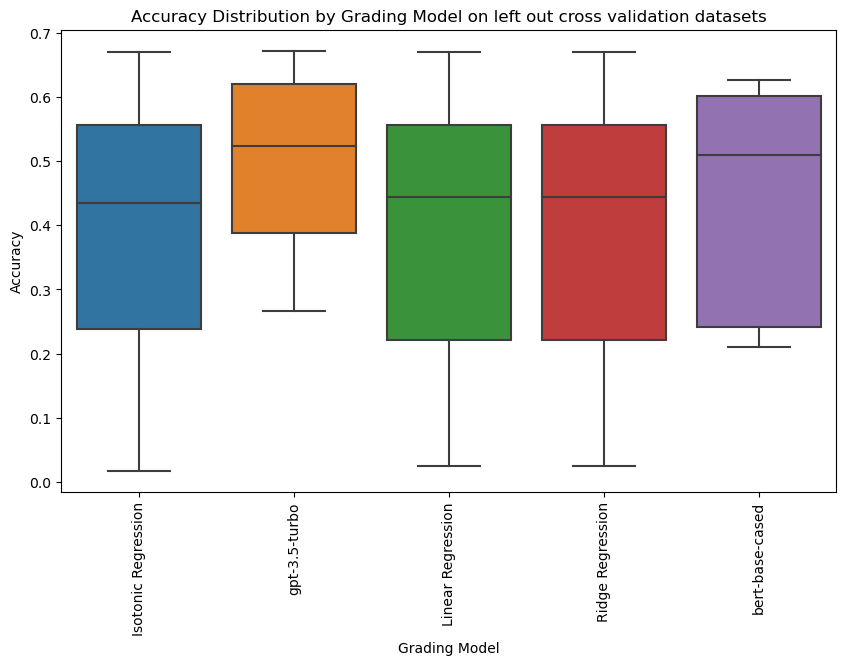

In [123]:
plt.figure(figsize=(10,6))
sns.boxplot(x='grading_model', y='f1_weighted', data=performance_concatenated_datasets)
plt.title('Accuracy Distribution by Grading Model on left out cross validation datasets')
plt.ylabel('Accuracy')
plt.xlabel('Grading Model')
plt.xticks(rotation=90)
plt.show()


# Performance Concatenated Datasets

In [45]:
performance_concatenated_domains = performance.query("dataset_name == 'concatenated_domains'")[["f1_weighted", "accuracy", "embedding_model_name", "grading_model", "left_out_dataset"]]
# left_out_dataset.notnull()

performance_concatenated_domains = performance_concatenated_domains.query("left_out_dataset.notnull()")


In [46]:
performance_concatenated_domains


,f1_weighted,accuracy,embedding_model_name,grading_model,left_out_dataset
37,0.499874,0.390312,gpt-3.5-turbo,gpt-3.5-turbo,biology
38,0.263177,0.328741,gpt-3.5-turbo,gpt-3.5-turbo,english_language_arts
39,0.479978,0.453669,gpt-3.5-turbo,gpt-3.5-turbo,english
40,0.507049,0.495356,gpt-3.5-turbo,gpt-3.5-turbo,neural_networks
41,0.364504,0.408568,gpt-3.5-turbo,gpt-3.5-turbo,science
...,...,...,...,...,...
4836,0.321091,0.322656,bert-base-cased,bert-base-cased,science
4837,0.631928,0.621875,bert-base-cased,bert-base-cased,science
4838,0.216927,0.270000,bert-base-cased,bert-base-cased,science
4851,0.513934,0.547988,gpt-3.5-turbo,gpt-3.5-turbo,neural_networks


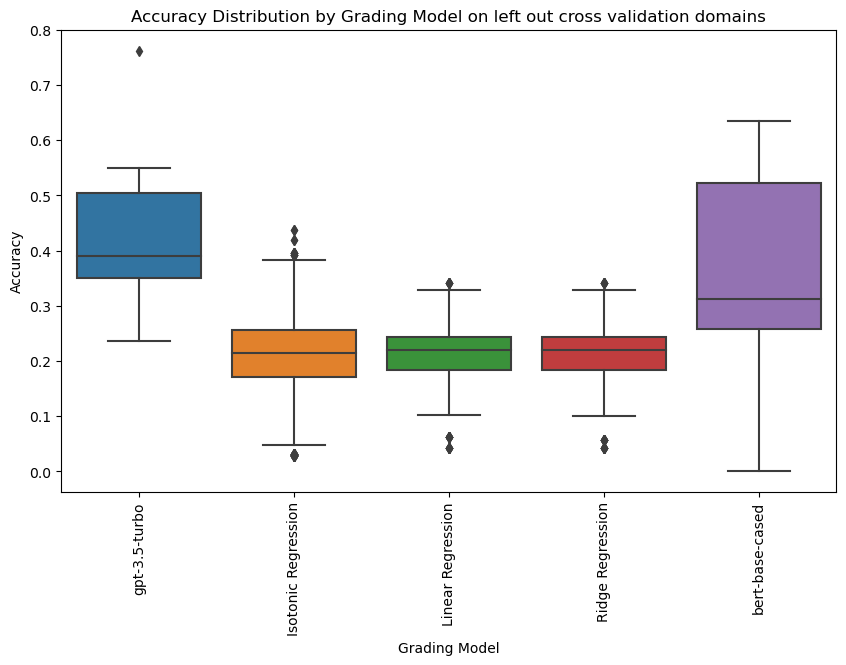

In [403]:
plt.figure(figsize=(10,6))
sns.boxplot(x='grading_model', y='f1_weighted', data=performance_concatenated_domains)
plt.title('Accuracy Distribution by Grading Model on left out cross validation domains')
plt.ylabel('Accuracy')
plt.xlabel('Grading Model')
plt.xticks(rotation=90)
plt.show()


# all experiements overview

In [205]:
# filter out unnecissary suff

# keep only zero shot with description
performance = performance.query('embedding_model_name != "gpt-3.5-turbo" or shots != 0 or description.notnull()')

# take out distilled bert
performance = performance.query('embedding_model_name != "distilbert-base-cased"')

# take out old names for embed_words_glove
performance = performance.query('embedding_model_name != "embed_words_glove"')

# take out old names for embed_words_fasttext
performance = performance.query('embedding_model_name != "embed_words_fasttext"')

# take out old names for embed_words_conceptnet
performance = performance.query('embedding_model_name != "embed_words_conceptnet"')


In [208]:
# keeping only the last of each experiement
# Convert the time_stamp column to datetime if it's not already
performance['time_stamp'] = pd.to_datetime(performance['time_stamp'])

# Sort by time_stamp
performance = performance.sort_values('time_stamp')

# Define the columns that identify each experiment
experiment_columns = ['embedding_model_name', 'grading_model', 'dataset_name', 'embedding_seperated', 'dataset_split', 'seed_data_split', 'left_out_dataset', 'sentence_embedding_method', 'feature_engenearing', 'shots', 'description', 'epochs']

# Drop duplicates, keeping only the last row of each experiment
performance = performance.drop_duplicates(subset=experiment_columns, keep='last')

# keep only validation results
performance = performance.query("dataset_split == 'validation'")


In [209]:
# update names to make more compact
def update_BERT_grading_model(row):
    if row['grading_model'] == 'bert-base-cased':
        return f"{row['grading_model']}_epochs_{row['epochs']}"
    else:
        return row['grading_model']

performance['grading_model'] = performance.apply(update_BERT_grading_model, axis=1)


In [210]:
# update names to make more compact
def update_GPT_grading_model(row):
    if row['grading_model'] == 'gpt-3.5-turbo':
        return f"{row['grading_model']}_shots_{row['shots']}"
    else:
        return row['grading_model']

performance['grading_model'] = performance.apply(update_GPT_grading_model, axis=1)


In [211]:
# update names to make more compact
def update_embed_sep_grading_model(row):
    if row['embedding_seperated'] == True:
        return f"{row['embedding_model_name']}_{row['sentence_embedding_method']}_{row['grading_model']}"
    else:
        return row['grading_model']

performance['grading_model'] = performance.apply(update_embed_sep_grading_model, axis=1)


In [213]:
def update_dataset_name(row):
    if row['dataset_name'] == 'concatenated_datasets' and pd.notnull(row['left_out_dataset']):
        return f"{row['dataset_name']}_left_out_{row['left_out_dataset']}"
    elif row['dataset_name'] == 'concatenated_domains' and pd.notnull(row['left_out_dataset']):
        return f"{row['dataset_name']}_left_out_{row['left_out_dataset']}"
    else:
        return row['dataset_name']

performance['dataset_name'] = performance.apply(update_dataset_name, axis=1)


In [443]:
# performance = performance.drop(columns=['embedding_seperated', 'embedding_model_name', "sentence_embedding_method", "feature_engenearing", "seed_data_split", "shots", "epochs", "description", "finished_pred", "last_pred_index", "time_stamp", "left_out_dataset"])


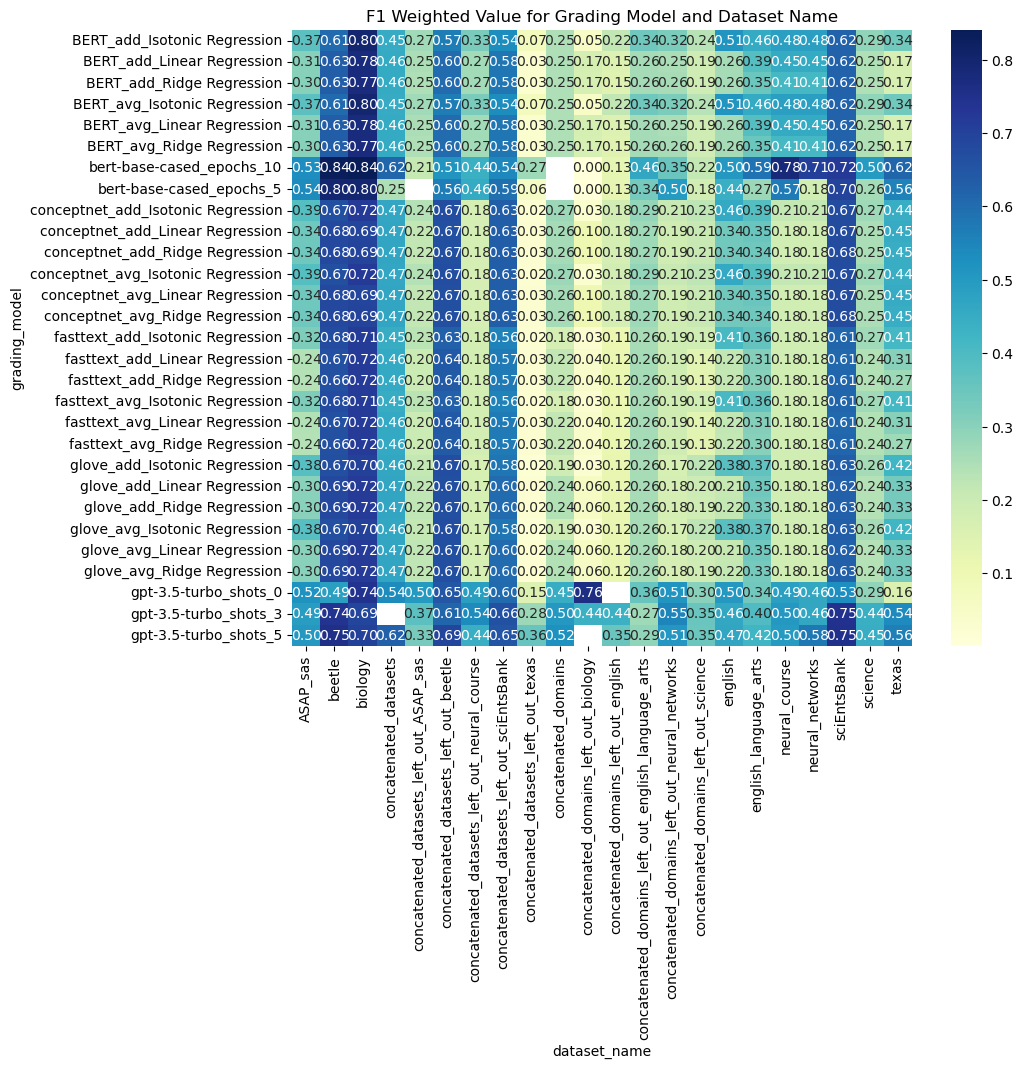

In [214]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create pivot table
pivot_table = performance.pivot_table('f1_weighted', 'grading_model', 'dataset_name')

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("F1 Weighted Value for Grading Model and Dataset Name")
plt.show()


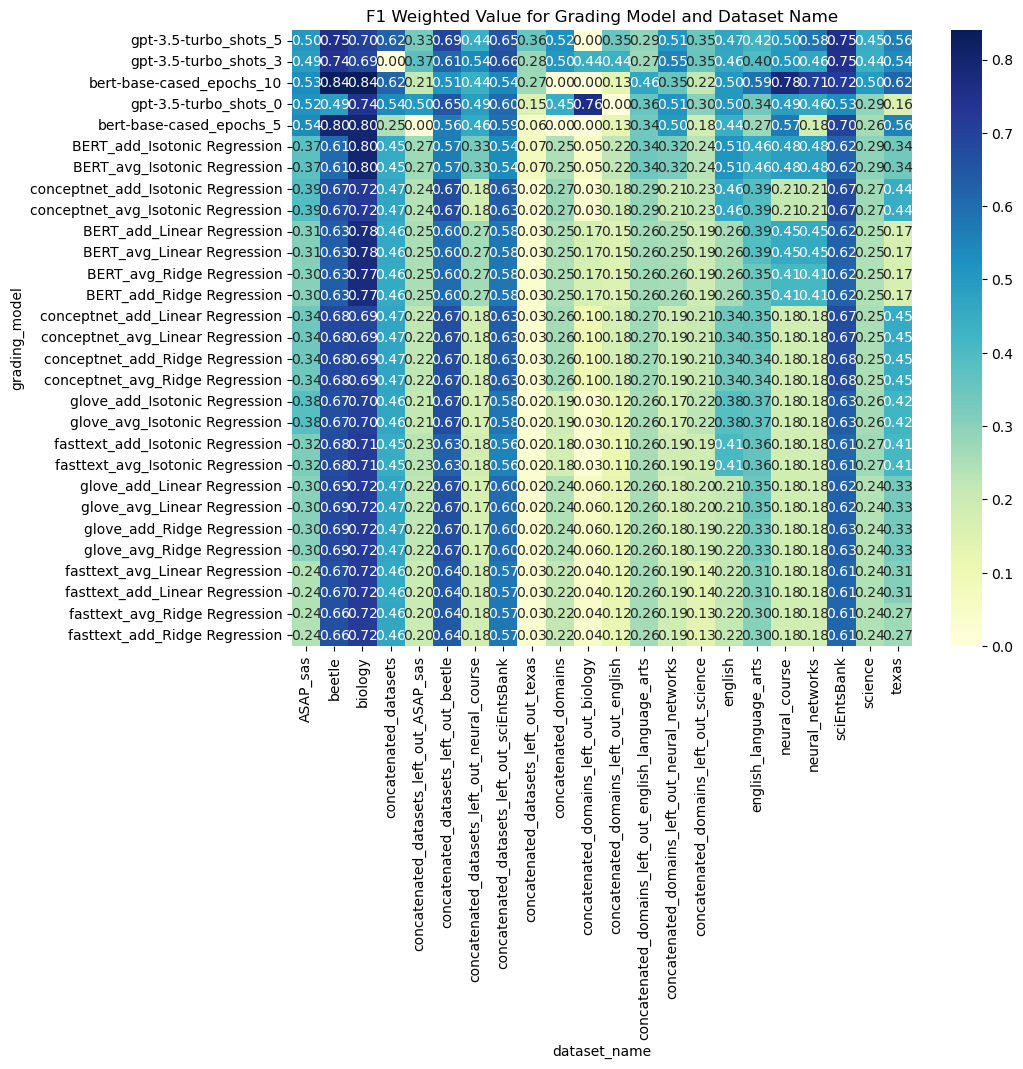

In [215]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the mean 'f1_weighted' value for each 'grading_model'
grading_model_order = performance.groupby('grading_model')['f1_weighted'].mean().sort_values(ascending=False).index

# Create pivot table
pivot_table = performance.pivot_table('f1_weighted', 'grading_model', 'dataset_name', fill_value=0)

# Reindex the pivot table according to the 'grading_model' order
pivot_table = pivot_table.reindex(grading_model_order)

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("F1 Weighted Value for Grading Model and Dataset Name")
plt.show()


In [450]:
performance = performance.query("embedding_seperated != True or (embedding_model_name == 'conceptnet' or embedding_model_name == 'BERT')")
performance = performance.query("embedding_seperated != True or (grading_model == 'BERT_avg_Isotonic Regression' or grading_model == 'conceptnet_avg_Isotonic Regression')")


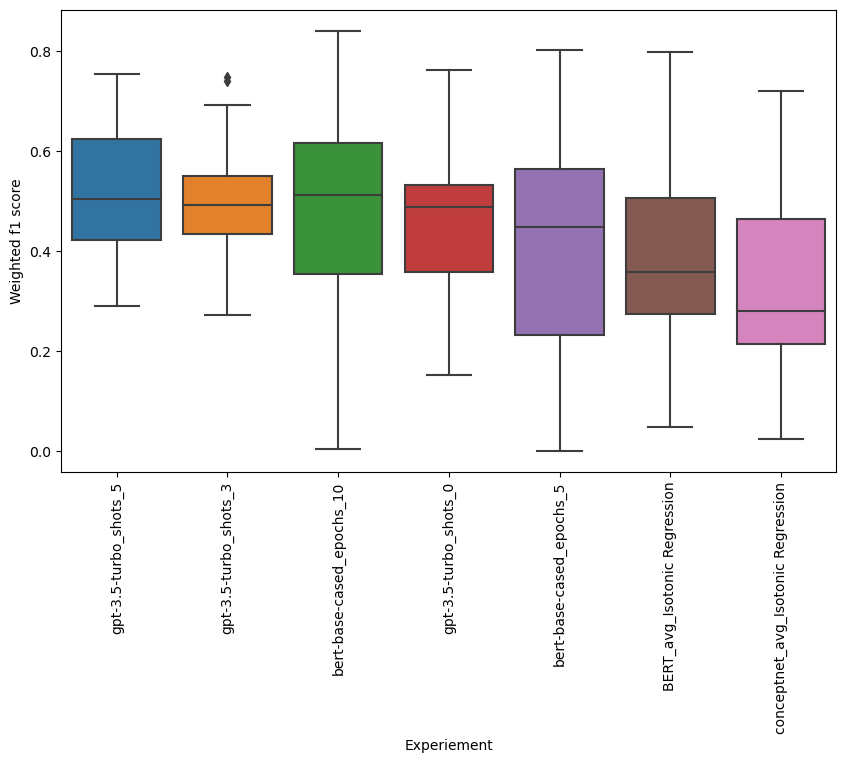

In [452]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the median 'f1_weighted' value for each 'grading_model'
grading_model_order = performance.groupby('grading_model')['f1_weighted'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10,6))
sns.boxplot(x='grading_model', y='f1_weighted', data=performance, order=grading_model_order)
# plt.title('Accuracy Distribution by Grading Model on left out cross validation datasets')
plt.ylabel('Weighted f1 score')
plt.xlabel('Experiement')
plt.xticks(rotation=90)
plt.show()


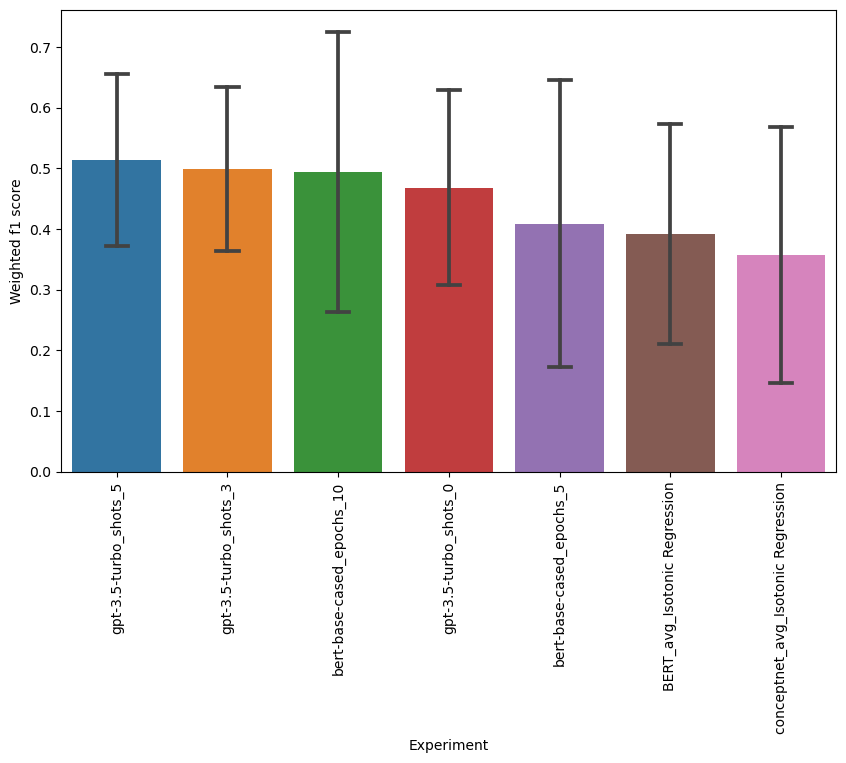

In [456]:
plt.figure(figsize=(10,6))
sns.barplot(x='grading_model', y='f1_weighted', data=performance, order=grading_model_order, ci='sd', capsize=0.2)
plt.ylabel('Weighted f1 score')
plt.xlabel('Experiment')
plt.xticks(rotation=90)
plt.show()


In [178]:
performance["grading_model"].unique()


array(['bert-base-cased_epochs_5', 'bert-base-cased_epochs_10',
       'gpt-3.5-turbo_shots_3', 'fasttext_avg_Ridge Regression',
       'fasttext_avg_Linear Regression',
       'fasttext_avg_Isotonic Regression',
       'fasttext_add_Ridge Regression',
       'fasttext_add_Isotonic Regression',
       'fasttext_add_Linear Regression', 'glove_avg_Isotonic Regression',
       'glove_avg_Ridge Regression', 'glove_avg_Linear Regression',
       'glove_add_Ridge Regression', 'glove_add_Linear Regression',
       'glove_add_Isotonic Regression', 'BERT_avg_Isotonic Regression',
       'BERT_avg_Linear Regression', 'BERT_avg_Ridge Regression',
       'BERT_add_Ridge Regression', 'BERT_add_Isotonic Regression',
       'BERT_add_Linear Regression', 'conceptnet_avg_Linear Regression',
       'conceptnet_avg_Isotonic Regression',
       'conceptnet_avg_Ridge Regression',
       'conceptnet_add_Linear Regression',
       'conceptnet_add_Isotonic Regression',
       'conceptnet_add_Ridge Regression'

In [430]:
performance.columns


Index(['row_id', 'embedding_seperated', 'embedding_model_name',
       'sentence_embedding_method', 'feature_engenearing', 'grading_model',
       'dataset_name', 'dataset_split', 'seed_data_split', 'left_out_dataset',
       'description', 'shots', 'epochs', 'finished_pred', 'last_pred_index',
       'time_stamp', 'rmse', 'pears_correlation', 'p_value', 'accuracy',
       'precision_macro', 'recall_macro', 'f1_macro', 'precision_micro',
       'recall_micro', 'f1_micro', 'precision_weighted', 'recall_weighted',
       'f1_weighted'],
      dtype='object')

In [25]:
performance.query("embedding_model_name == 'gpt-3.5-turbo'")['f1_weighted']


AttributeError: 'Series' object has no attribute 'nan'

In [455]:
performance.query("embedding_model_name == 'bert-base-cased'")['f1_weighted'].std()


0.23449763887056205

In [38]:
from scipy.stats import shapiro

performance = performance.dropna(subset=['f1_weighted'])

models = performance['grading_model'].unique()

for model in models:
    stat, p = shapiro(performance[performance['grading_model'] == model]['f1_weighted'])
    print(f'{model} - Statistics={stat}, p={p}')


bert-base-cased_epochs_5 - Statistics=0.9614804983139038, p=0.5738343596458435
bert-base-cased_epochs_10 - Statistics=0.9638476371765137, p=0.5967309474945068
gpt-3.5-turbo_shots_3 - Statistics=0.9618337750434875, p=0.5538139939308167
Ridge Regression - Statistics=0.8926640748977661, p=5.781263245907553e-10
Linear Regression - Statistics=0.8967933654785156, p=1.0079626022729826e-09
Isotonic Regression - Statistics=0.953834056854248, p=1.608600177860353e-05
gpt-3.5-turbo_shots_5 - Statistics=0.9538324475288391, p=0.40149691700935364
gpt-3.5-turbo_shots_0 - Statistics=0.9481433033943176, p=0.31404927372932434


In [35]:
performance["grading_model"].unique()

array(['bert-base-cased_epochs_5', 'bert-base-cased_epochs_10',
       'gpt-3.5-turbo_shots_3', 'Ridge Regression', 'Linear Regression',
       'Isotonic Regression', 'gpt-3.5-turbo_shots_5',
       'gpt-3.5-turbo_shots_0'], dtype=object)

In [36]:
import scipy.stats as stats

# Create lists of f1_weighted scores for each grading model
data_model1 = performance[performance['grading_model'] == 'Ridge Regression']['f1_weighted'].tolist()
data_model2 = performance[performance['grading_model'] == 'Linear Regression']['f1_weighted'].tolist()
data_model3 = performance[performance['grading_model'] == 'Isotonic Regression']['f1_weighted'].tolist()

data_model4 = performance[performance['grading_model'] == 'bert-base-cased_epochs_5']['f1_weighted'].tolist()
data_model5 = performance[performance['grading_model'] == 'bert-base-cased_epochs_10']['f1_weighted'].tolist()

data_model6 = performance[performance['grading_model'] == 'gpt-3.5-turbo_shots_0']['f1_weighted'].tolist()
data_model7 = performance[performance['grading_model'] == 'gpt-3.5-turbo_shots_3']['f1_weighted'].tolist()
data_model8 = performance[performance['grading_model'] == 'gpt-3.5-turbo_shots_5']['f1_weighted'].tolist()

# Perform Kruskal-Wallis H test
H, pval = stats.kruskal(data_model1, data_model2, data_model3, data_model4, data_model5, data_model6, data_model7, data_model8)

print(f"H statistic: {H}")
print(f"p-value: {pval}")


H statistic: 49.45132073748278
p-value: 1.8508299018095994e-08


In [37]:
import scikit_posthocs as sp

# Create a new dataframe where 'grading_model' and 'f1_weighted' are not NaN
df_not_nan = performance.dropna(subset=['grading_model', 'f1_weighted'])

# Perform Dunn's Test
posthoc = sp.posthoc_dunn(df_not_nan, val_col='f1_weighted', group_col='grading_model', p_adjust='bonferroni')

posthoc


,Isotonic Regression,Linear Regression,Ridge Regression,bert-base-cased_epochs_10,bert-base-cased_epochs_5,gpt-3.5-turbo_shots_0,gpt-3.5-turbo_shots_3,gpt-3.5-turbo_shots_5
Isotonic Regression,1.000000,1.000000,1.000000,0.206169,1.0,0.314538,0.022636,0.008925
Linear Regression,1.000000,1.000000,1.000000,0.033164,1.0,0.054553,0.002557,0.000883
Ridge Regression,1.000000,1.000000,1.000000,0.027726,1.0,0.045922,0.002070,0.000706
bert-base-cased_epochs_10,0.206169,0.033164,0.027726,1.000000,1.0,1.000000,1.000000,1.000000
bert-base-cased_epochs_5,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000
gpt-3.5-turbo_shots_0,0.314538,0.054553,0.045922,1.000000,1.0,1.000000,1.000000,1.000000
gpt-3.5-turbo_shots_3,0.022636,0.002557,0.002070,1.000000,1.0,1.000000,1.000000,1.000000
gpt-3.5-turbo_shots_5,0.008925,0.000883,0.000706,1.000000,1.0,1.000000,1.000000,1.000000


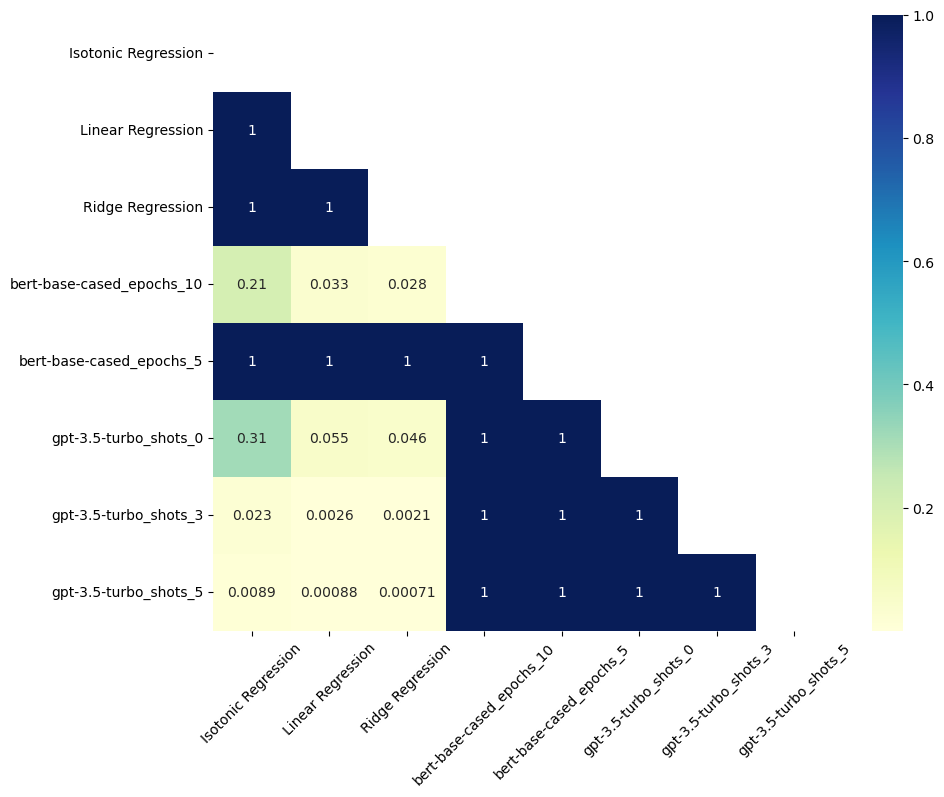

In [41]:
import numpy as np

mask = np.triu(np.ones_like(posthoc, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(posthoc, annot=True, cmap='YlGnBu', mask=mask)

# plt.title("Dunn's Post-hoc Test")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()


In [23]:
len(data_model1)
len(data_model2)
len(data_model3)
len(data_model4)

132

In [19]:
import scipy.stats as stats

# Create lists of f1_weighted scores for each grading model
data_model1 = performance[performance['embedding_model_name'] == 'fasttext']['f1_weighted'].tolist()
data_model2 = performance[performance['embedding_model_name'] == 'glove']['f1_weighted'].tolist()
data_model3 = performance[performance['embedding_model_name'] == 'BERT']['f1_weighted'].tolist()
data_model4 = performance[performance['embedding_model_name'] == 'conceptnet']['f1_weighted'].tolist()

# Perform Kruskal-Wallis H test
H, pval = stats.kruskal(data_model1, data_model2, data_model3, data_model4)

print(f"H statistic: {H}")
print(f"p-value: {pval}")


H statistic: 10.291156405056084
p-value: 0.016246634142870555


In [9]:
import scikit_posthocs as sp

# Combine all data into a single DataFrame
all_data = pd.DataFrame({
    'embedding_model_name': ['fasttext']*len(data_model1) + ['glove']*len(data_model2) + ['BERT']*len(data_model3) + ['conceptnet']*len(data_model4),
    'f1_weighted': data_model1 + data_model2 + data_model3 + data_model4
})

# Run Dunn's test
posthoc = sp.posthoc_dunn(all_data, val_col='f1_weighted', group_col='embedding_model_name', p_adjust='holm')

print(posthoc)


                BERT  conceptnet  fasttext     glove
BERT        1.000000    0.659366  0.025057  0.087231
conceptnet  0.659366    1.000000  0.235143  0.482373
fasttext    0.025057    0.235143  1.000000  0.659366
glove       0.087231    0.482373  0.659366  1.000000


## do the same thing but with datasets and only using BERT's, GPT's and BERT_avg_Isotomic and conceptnet_avg_Isotomic

In [80]:
performance = performance.query("grading_model == 'conceptnet_avg_Isotonic Regression' or grading_model == 'BERT_avg_Isotonic Regression' or grading_model == 'gpt-3.5-turbo_shots_0' or grading_model == 'gpt-3.5-turbo_shots_3' or grading_model == 'gpt-3.5-turbo_shots_5' or grading_model == 'bert-base-cased_epochs_5' or grading_model == 'bert-base-cased_epochs_10'")


In [81]:
performance["dataset_name"].unique()


array(['beetle', 'english', 'texas', 'neural_course',
       'concatenated_datasets', 'concatenated_datasets_left_out_ASAP_sas',
       'concatenated_datasets_left_out_beetle',
       'concatenated_datasets_left_out_neural_course',
       'concatenated_datasets_left_out_texas',
       'concatenated_datasets_left_out_sciEntsBank',
       'concatenated_domains', 'science', 'ASAP_sas', 'sciEntsBank',
       'biology', 'neural_networks', 'english_language_arts'],
      dtype=object)

In [85]:
from scipy.stats import shapiro

performance = performance.dropna(subset=['f1_weighted'])

datasets = performance['dataset_name'].unique()

for dataset in datasets:
    stat, p = shapiro(performance[performance['dataset_name'] == dataset]['f1_weighted'])
    print(f'{dataset} - Statistics={stat}, p={p}')


beetle - Statistics=0.942423939704895, p=0.6606408357620239
english - Statistics=0.8945503234863281, p=0.29924944043159485
texas - Statistics=0.8683264851570129, p=0.17946207523345947
neural_course - Statistics=0.8788427710533142, p=0.22136077284812927
concatenated_datasets - Statistics=0.8951038122177124, p=0.3457978367805481
concatenated_datasets_left_out_ASAP_sas - Statistics=0.9268582463264465, p=0.5560669898986816
concatenated_datasets_left_out_beetle - Statistics=0.9500992894172668, p=0.7306030988693237
concatenated_datasets_left_out_neural_course - Statistics=0.8708900213241577, p=0.18898168206214905
concatenated_datasets_left_out_texas - Statistics=0.9094385504722595, p=0.39199957251548767
concatenated_datasets_left_out_sciEntsBank - Statistics=0.9181135892868042, p=0.4548810124397278
concatenated_domains - Statistics=0.9759260416030884, p=0.574059784412384
science - Statistics=0.8188340663909912, p=0.06257769465446472
ASAP_sas - Statistics=0.7951329350471497, p=0.0366530269384

In [86]:
import scipy.stats as stats

datasets = ['beetle', 'english', 'texas', 'neural_course', 'concatenated_datasets', 
            'concatenated_datasets_left_out_ASAP_sas', 'concatenated_datasets_left_out_beetle',
            'concatenated_datasets_left_out_neural_course', 'concatenated_datasets_left_out_texas',
            'concatenated_datasets_left_out_sciEntsBank', 'concatenated_domains', 'science', 
            'ASAP_sas', 'sciEntsBank', 'biology', 'neural_networks', 'english_language_arts']

data_lists = []
for dataset in datasets:
    data_list = performance[performance['dataset_name'] == dataset]['f1_weighted'].dropna().tolist()
    data_lists.append(data_list)

# Perform Kruskal-Wallis H test
H, pval = stats.kruskal(*data_lists)

print(f"H statistic: {H}")
print(f"p-value: {pval}")


H statistic: 89.39763245959541
p-value: 3.2295985691580832e-12


In [87]:
import scikit_posthocs as sp

# Create a new dataframe where 'dataset_name' and 'f1_weighted' are not NaN
df_not_nan = performance.dropna(subset=['dataset_name', 'f1_weighted'])

# Perform Dunn's Test
posthoc = sp.posthoc_dunn(df_not_nan, val_col='f1_weighted', group_col='dataset_name', p_adjust='bonferroni')

posthoc


,ASAP_sas,beetle,biology,concatenated_datasets,concatenated_datasets_left_out_ASAP_sas,concatenated_datasets_left_out_beetle,concatenated_datasets_left_out_neural_course,concatenated_datasets_left_out_sciEntsBank,concatenated_datasets_left_out_texas,concatenated_domains,english,english_language_arts,neural_course,neural_networks,sciEntsBank,science,texas
ASAP_sas,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.796604,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
beetle,1.000000,1.000000,1.000000,1.000000,0.043119,1.000000,0.519248,1.000000,0.000363,0.000346,1.0,0.529648,1.000000,1.000000,1.000000,0.080521,1.0
biology,1.000000,1.000000,1.000000,1.000000,0.005813,1.000000,0.090296,1.000000,0.000026,0.000011,1.0,0.092379,1.000000,0.479479,1.000000,0.010787,1.0
concatenated_datasets,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.782828,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
concatenated_datasets_left_out_ASAP_sas,1.000000,0.043119,0.005813,1.000000,1.000000,0.239567,1.000000,0.254631,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,0.040233,1.000000,1.0
concatenated_datasets_left_out_beetle,1.000000,1.000000,1.000000,1.000000,0.239567,1.000000,1.000000,1.000000,0.003597,0.006545,1.0,1.000000,1.000000,1.000000,1.000000,0.442500,1.0
concatenated_datasets_left_out_neural_course,1.000000,0.519248,0.090296,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,0.489152,1.000000,1.0
concatenated_datasets_left_out_sciEntsBank,1.000000,1.000000,1.000000,1.000000,0.254631,1.000000,1.000000,1.000000,0.003906,0.007262,1.0,1.000000,1.000000,1.000000,1.000000,0.469979,1.0
concatenated_datasets_left_out_texas,0.796604,0.000363,0.000026,0.782828,1.000000,0.003597,1.000000,0.003906,1.000000,1.000000,1.0,1.000000,0.499003,1.000000,0.000331,1.000000,1.0
concatenated_domains,1.000000,0.000346,0.000011,1.000000,1.000000,0.006545,1.000000,0.007262,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,0.000307,1.000000,1.0


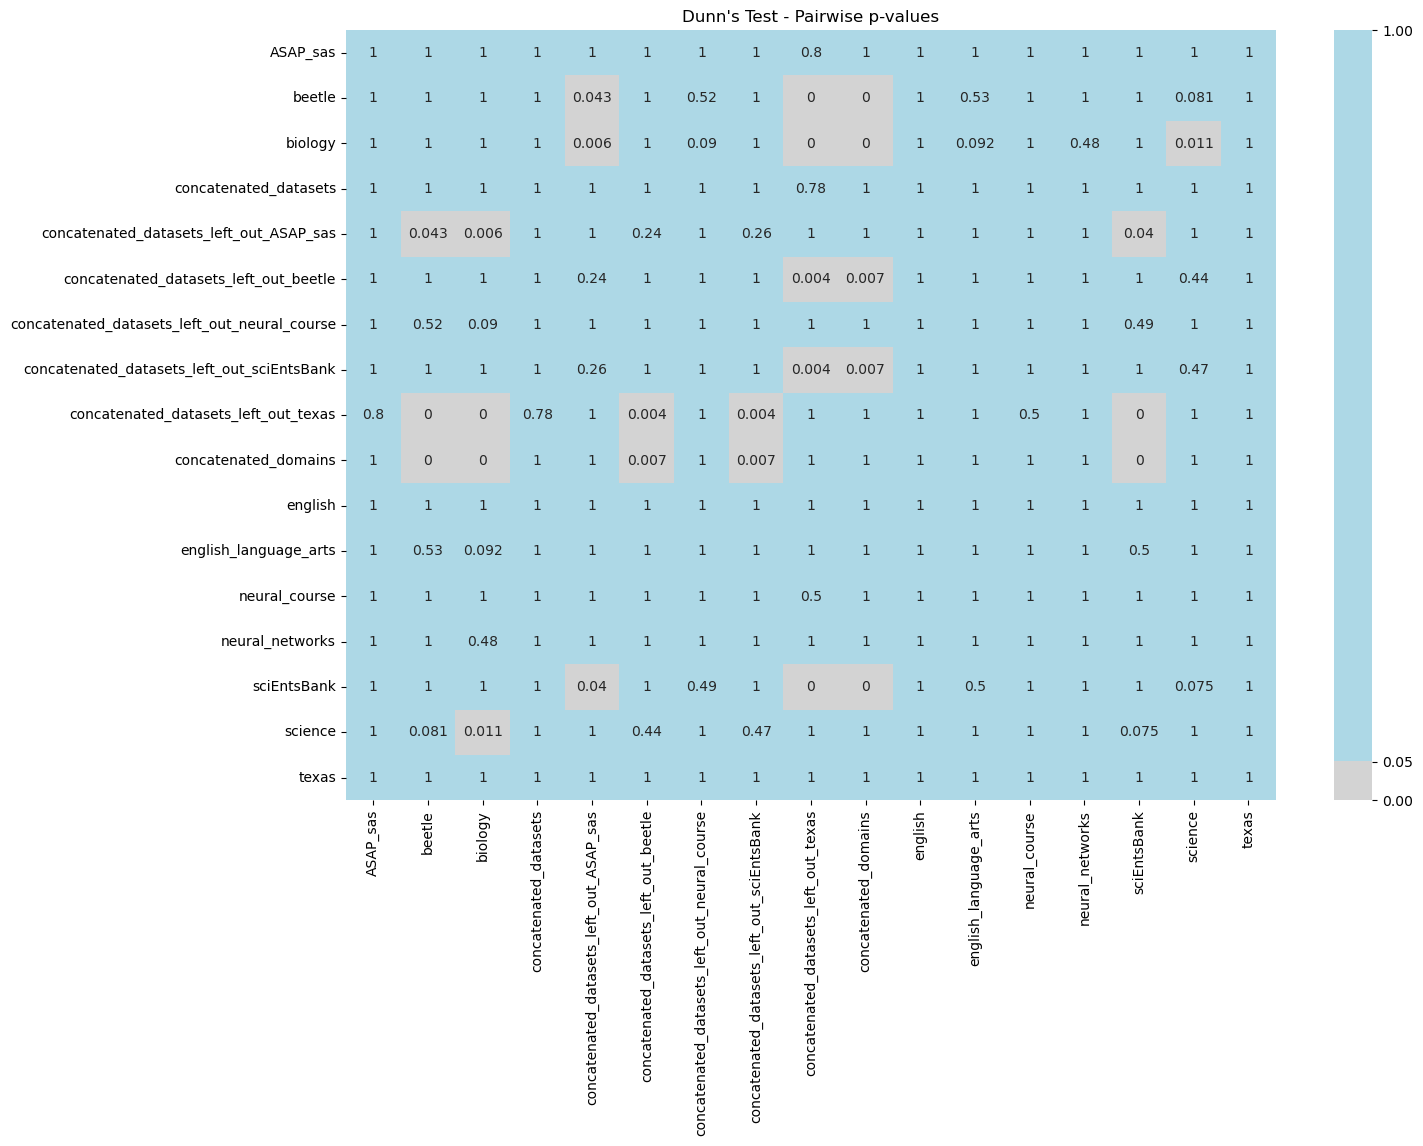

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt

# Round the p-values to 3 decimal places
posthoc_rounded = posthoc.round(3)

# Define a custom color map: light blue for p < 0.05, light gray otherwise
cmap = sns.color_palette(['lightgreen', 'gray'])

plt.figure(figsize=(15, 10))  # Set heatmap size
sns.heatmap(posthoc_rounded, annot=True, cmap=cmap, center=0.05, cbar_kws={'ticks': [0, 0.05, 1]}, vmin=0, vmax=1, mask=mask)
# plt.title('Dunn\'s Test - Pairwise p-values')  # Add title to the heatmap
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.yticks(rotation=0)  # Rotate y-axis labels for better readability
plt.show()  # Display the heatmap


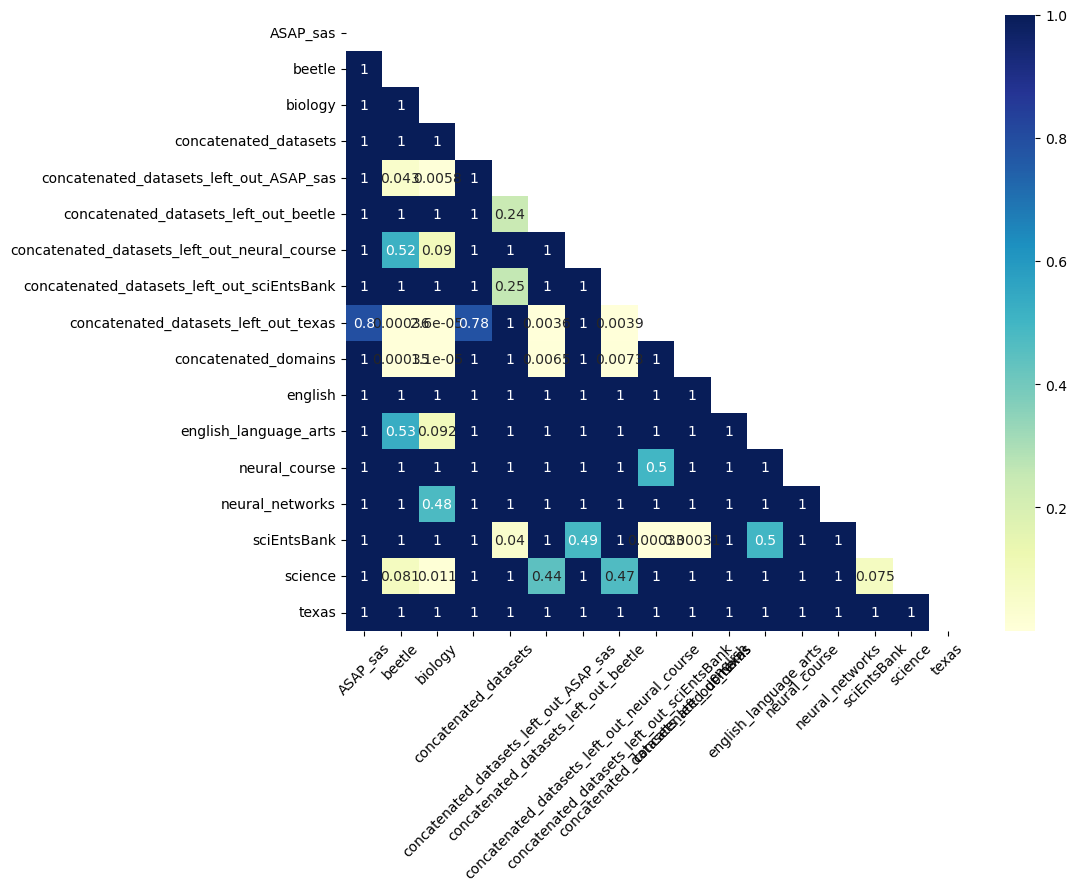

In [89]:
import numpy as np

mask = np.triu(np.ones_like(posthoc, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(posthoc, annot=True, cmap='YlGnBu', mask=mask)

# plt.title("Dunn's Post-hoc Test")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()


## BERT

In [182]:
bert_five = performance.query("grading_model == 'bert-base-cased_epochs_5'")
bert_ten = performance.query("grading_model == 'bert-base-cased_epochs_10'")

In [183]:
bert_five["f1_weighted"].median()


0.44925240649082704

In [184]:
print(f"Q1: {bert_five['f1_weighted'].quantile(0.25)}")
print(f"Q1: {bert_ten['f1_weighted'].quantile(0.25)}")

print(f"median: {bert_five['f1_weighted'].median()}")
print(f"median: {bert_ten['f1_weighted'].median()}")

print(f"Q3: {bert_five['f1_weighted'].quantile(0.75)}")
print(f"Q3: {bert_ten['f1_weighted'].quantile(0.75)}")

print(f"mean: {bert_five['f1_weighted'].mean()}")
print(f"mean: {bert_ten['f1_weighted'].mean()}")

print(f"std: {bert_five['f1_weighted'].std()}")
print(f"std: {bert_ten['f1_weighted'].std()}")


Q1: 0.23269475354329366
Q1: 0.3546861195070913
median: 0.44925240649082704
median: 0.5128444726005702
Q3: 0.5643504126395693
Q3: 0.6167306540678424
mean: 0.40910245357154873
mean: 0.4946135883742361
std: 0.2363486740263511
std: 0.23057617969753189


In [168]:
print(f"mean: {bert_five['f1_weighted'].mean()}")
print(f"mean: {bert_five['f1_weighted'].mean()}")


mean: 0.40910245357154873
mean: 0.40910245357154873


In [112]:
bert_five["f1_weighted"].mean()

0.40910245357154873

In [113]:
bert_ten["f1_weighted"].mean()

0.4946135883742361

## GPT

In [132]:
performance.columns

Index(['row_id', 'embedding_seperated', 'embedding_model_name',
       'sentence_embedding_method', 'feature_engenearing', 'grading_model',
       'dataset_name', 'dataset_split', 'seed_data_split', 'left_out_dataset',
       'description', 'shots', 'epochs', 'finished_pred', 'last_pred_index',
       'time_stamp', 'rmse', 'pears_correlation', 'p_value', 'accuracy',
       'precision_macro', 'recall_macro', 'f1_macro', 'precision_micro',
       'recall_micro', 'f1_micro', 'precision_weighted', 'recall_weighted',
       'f1_weighted'],
      dtype='object')

In [114]:
performance["grading_model"].unique()

array(['bert-base-cased_epochs_5', 'bert-base-cased_epochs_10',
       'gpt-3.5-turbo_shots_3', 'BERT_avg_Isotonic Regression',
       'conceptnet_avg_Isotonic Regression', 'gpt-3.5-turbo_shots_5',
       'gpt-3.5-turbo_shots_0'], dtype=object)

In [129]:
performance["dataset_name"].unique()

array(['beetle', 'english', 'texas', 'neural_course',
       'concatenated_datasets', 'concatenated_datasets_left_out_ASAP_sas',
       'concatenated_datasets_left_out_beetle',
       'concatenated_datasets_left_out_neural_course',
       'concatenated_datasets_left_out_texas',
       'concatenated_datasets_left_out_sciEntsBank',
       'concatenated_domains', 'science', 'ASAP_sas', 'sciEntsBank',
       'biology', 'neural_networks', 'english_language_arts'],
      dtype=object)

In [115]:
gpt_zero = performance.query("grading_model == 'gpt-3.5-turbo_shots_0'")
gpt_three = performance.query("grading_model == 'gpt-3.5-turbo_shots_3'")
gpt_five = performance.query("grading_model == 'gpt-3.5-turbo_shots_5'")


In [163]:
print(gpt_zero["rmse"].quantile(0.75))
print(gpt_three["rmse"].quantile(0.75))
print(gpt_five["rmse"].quantile(0.75))


56.331359811456544
50.179151391312466
51.13146965164752


In [165]:
print(gpt_zero["rmse"].mean())
print(gpt_three["rmse"].mean())
print(gpt_five["rmse"].mean())


43.34979207707194
33.26646949887064
46.90993588264774


In [119]:
## GPT

In [157]:
performance.query("grading_model == 'bert-base-cased_epochs_10' and dataset_name == 'ASAP_sas'")[["rmse", "pears_correlation"]]


,rmse,pears_correlation
4811,0.724299,0.619819


## regressions

In [ ]:
['bert-base-cased_epochs_5', 'bert-base-cased_epochs_10',
       'gpt-3.5-turbo_shots_3', 'fasttext_avg_Ridge Regression',
       'fasttext_avg_Linear Regression',
       'fasttext_avg_Isotonic Regression',
       'fasttext_add_Ridge Regression',
       'fasttext_add_Isotonic Regression',
       'fasttext_add_Linear Regression', 'glove_avg_Isotonic Regression',
       'glove_avg_Ridge Regression', 'glove_avg_Linear Regression',
       'glove_add_Ridge Regression', 'glove_add_Linear Regression',
       'glove_add_Isotonic Regression', 'BERT_avg_Isotonic Regression',
       'BERT_avg_Linear Regression', 'BERT_avg_Ridge Regression',
       'BERT_add_Ridge Regression', 'BERT_add_Isotonic Regression',
       'BERT_add_Linear Regression', 'conceptnet_avg_Linear Regression',
       'conceptnet_avg_Isotonic Regression',
       'conceptnet_avg_Ridge Regression',
       'conceptnet_add_Linear Regression',
       'conceptnet_add_Isotonic Regression',
       'conceptnet_add_Ridge Regression', 'gpt-3.5-turbo_shots_5',
       'gpt-3.5-turbo_shots_0']

In [179]:
fasttext_avg_ridge = performance.query("grading_model == 'fasttext_avg_Ridge Regression'")
fasttext_avg_linear = performance.query("grading_model == 'fasttext_avg_Linear Regression'")
fasttext_avg_isotonic = performance.query("grading_model == 'fasttext_avg_Isotonic Regression'")
fasttext_add_ridge = performance.query("grading_model == 'fasttext_add_Ridge Regression'")
fasttext_add_isotonic = performance.query("grading_model == 'fasttext_add_Isotonic Regression'")
fasttext_add_linear = performance.query("grading_model == 'fasttext_add_Linear Regression'")

glove_avg_isotonic = performance.query("grading_model == 'glove_avg_Isotonic Regression'")
glove_avg_ridge = performance.query("grading_model == 'glove_avg_Ridge Regression'")
glove_avg_linear = performance.query("grading_model == 'glove_avg_Linear Regression'")
glove_add_ridge = performance.query("grading_model == 'glove_add_Ridge Regression'")
glove_add_linear = performance.query("grading_model == 'glove_add_Linear Regression'")
glove_add_isotonic = performance.query("grading_model == 'glove_add_Isotonic Regression'")

bert_avg_isotonic = performance.query("grading_model == 'BERT_avg_Isotonic Regression'")
bert_avg_linear = performance.query("grading_model == 'BERT_avg_Linear Regression'")
bert_avg_ridge = performance.query("grading_model == 'BERT_avg_Ridge Regression'")
bert_add_ridge = performance.query("grading_model == 'BERT_add_Ridge Regression'")
bert_add_isotonic = performance.query("grading_model == 'BERT_add_Isotonic Regression'")
bert_add_linear = performance.query("grading_model == 'BERT_add_Linear Regression'")

conceptnet_avg_linear = performance.query("grading_model == 'conceptnet_avg_Linear Regression'")
conceptnet_avg_isotonic = performance.query("grading_model == 'conceptnet_avg_Isotonic Regression'")
conceptnet_avg_ridge = performance.query("grading_model == 'conceptnet_avg_Ridge Regression'")
conceptnet_add_linear = performance.query("grading_model == 'conceptnet_add_Linear Regression'")
conceptnet_add_isotonic = performance.query("grading_model == 'conceptnet_add_Isotonic Regression'")
conceptnet_add_ridge = performance.query("grading_model == 'conceptnet_add_Ridge Regression'")


In [180]:
models = [fasttext_avg_ridge, fasttext_avg_linear, fasttext_avg_isotonic, fasttext_add_ridge, fasttext_add_isotonic, fasttext_add_linear,
glove_avg_isotonic, glove_avg_ridge, glove_avg_linear, glove_add_ridge, glove_add_linear, glove_add_isotonic,
bert_avg_isotonic, bert_avg_linear, bert_avg_ridge, bert_add_ridge, bert_add_isotonic, bert_add_linear,
conceptnet_avg_linear, conceptnet_avg_isotonic, conceptnet_avg_ridge, conceptnet_add_linear, conceptnet_add_isotonic, conceptnet_add_ridge]

model_names = ['fasttext_avg_Ridge Regression', 'fasttext_avg_Linear Regression', 'fasttext_avg_Isotonic Regression', 
'fasttext_add_Ridge Regression', 'fasttext_add_Isotonic Regression', 'fasttext_add_Linear Regression',
'glove_avg_Isotonic Regression', 'glove_avg_Ridge Regression', 'glove_avg_Linear Regression', 
'glove_add_Ridge Regression', 'glove_add_Linear Regression', 'glove_add_Isotonic Regression', 
'BERT_avg_Isotonic Regression', 'BERT_avg_Linear Regression', 'BERT_avg_Ridge Regression', 
'BERT_add_Ridge Regression', 'BERT_add_Isotonic Regression', 'BERT_add_Linear Regression', 
'conceptnet_avg_Linear Regression', 'conceptnet_avg_Isotonic Regression', 'conceptnet_avg_Ridge Regression', 
'conceptnet_add_Linear Regression', 'conceptnet_add_Isotonic Regression', 'conceptnet_add_Ridge Regression']

for i, model in enumerate(models):
    print(f"Model: {model_names[i]}")
    print(f"Q1: {model['f1_weighted'].quantile(0.25)}")
    print(f"median: {model['f1_weighted'].median()}")
    print(f"Q3: {model['f1_weighted'].quantile(0.75)}")
    print(f"mean: {model['f1_weighted'].mean()}")
    print(f"std: {model['f1_weighted'].std()}")
    print("\n")


Model: fasttext_avg_Ridge Regression
Q1: 0.1849650349650349
median: 0.2297257493847145
Q3: 0.42081523956406974
mean: 0.30363526973321736
std: 0.2080301921799642


Model: fasttext_avg_Linear Regression
Q1: 0.1849650349650349
median: 0.2305088528726171
Q3: 0.42181659913511704

... [truncated: repetitive log output] ...

mean: 0.3430668649977167
std: 0.20768172978207738




In [207]:
performance.query("dataset_name == 'concatenated_domains'")

,row_id,embedding_seperated,embedding_model_name,sentence_embedding_method,feature_engenearing,grading_model,dataset_name,dataset_split,seed_data_split,left_out_dataset,...,accuracy,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,precision_weighted,recall_weighted,f1_weighted
360,358,True,fasttext,avg,cosine_similarity,Isotonic Regression,concatenated_domains,validation,42,NaN,...,0.280676,0.236786,0.186492,0.117532,0.280676,0.280676,0.280676,0.443092,0.280676,0.177892
361,359,True,fasttext,avg,cosine_similarity,Isotonic Regression,concatenated_domains,validation,42,biology,...,0.092428,0.295484,0.317606,0.079887,0.092428,0.092428,0.092428,0.834188,0.092428,0.027294
362,360,True,fasttext,avg,cosine_similarity,Isotonic Regression,concatenated_domains,validation,42,english_language_arts,...,0.429319,0.365263,0.333621,0.201143,0.429319,0.429319,0.429319,0.428073,0.429319,0.258708
363,361,True,fasttext,avg,cosine_similarity,Isotonic Regression,concatenated_domains,validation,42,english,...,0.254262,0.352038,0.336325,0.142710,0.254262,0.254262,0.254262,0.368427,0.254262,0.110712
364,362,True,fasttext,avg,cosine_similarity,Isotonic Regression,concatenated_domains,validation,42,neural_networks,...,0.337461,0.193531,0.350028,0.213935,0.337461,0.337461,0.337461,0.150998,0.337461,0.191192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4837,4835,False,bert-base-cased,NaN,NaN,bert-base-cased,concatenated_domains,test,42,science,...,0.621875,0.466998,0.457061,0.457088,0.621875,0.621875,0.621875,0.654688,0.621875,0.631928
4838,4836,False,bert-base-cased,NaN,NaN,bert-base-cased,concatenated_domains,validation,42,science,...,0.270000,0.155306,0.211626,0.155028,0.270000,0.270000,0.270000,0.223703,0.270000,0.216927
4850,4848,False,gpt-3.5-turbo,NaN,NaN,gpt-3.5-turbo,concatenated_domains,validation,42,NaN,...,0.495281,0.380435,0.272223,0.252933,0.495281,0.495281,0.495281,0.507675,0.495281,0.447164
4851,4849,False,gpt-3.5-turbo,NaN,NaN,gpt-3.5-turbo,concatenated_domains,validation,42,neural_networks,...,0.547988,0.390098,0.437876,0.362987,0.547988,0.547988,0.547988,0.576889,0.547988,0.513934
